# Benchmark: PXD014777 HeLa 10 replicate dataset

In this notebook, the results of running multiple tests are visualized.
It is assumed that the corresponding multi test script has been run prior to the visualizations section in this notebook.

In [2]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pipp.utils
import pipp

## Optional: Preparing MSMS sequence embeddings

If you want to use sequence embeddings for the MSMS data (prototypes), then run the following code to get the sequence of each prototype first. Afterwards run the script which computes the sequence embeddings for each prototype in `scripts/`.

In [3]:
PRETRAINED_MODEL_PATH = "../../checkpoints/checkpoint1.pth"
HELA_MSMS_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"

In [4]:
df_msms_hela = pd.read_csv(HELA_MSMS_OUT_PATH, low_memory=False)

In [5]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [6]:
prototype_sequences = model.get_prototype_sequences(df_msms_hela)

In [7]:
dir = "../../outputs"
os.makedirs(dir, exist_ok=True)

filename = "prototype_sequences.pkl"
path = os.path.join(dir, filename)

with open(path, "wb") as f:
    pickle.dump(prototype_sequences, f)

At this point you should generate the sequence embeddings with the associated script.


## Visualizing the results

Load the results from the test runs.


In [19]:
RESULTS_DIR = "../../results"

files = os.listdir(RESULTS_DIR)

results = []
for file in files:
    if not file.endswith(".pkl"):
        continue

    path = os.path.join(RESULTS_DIR, file)

    with open(path, "rb") as f:
        result = pickle.load(f)

    result = pipp.utils.flat_dict(result)
    results.append(result)

df = pd.DataFrame(results)

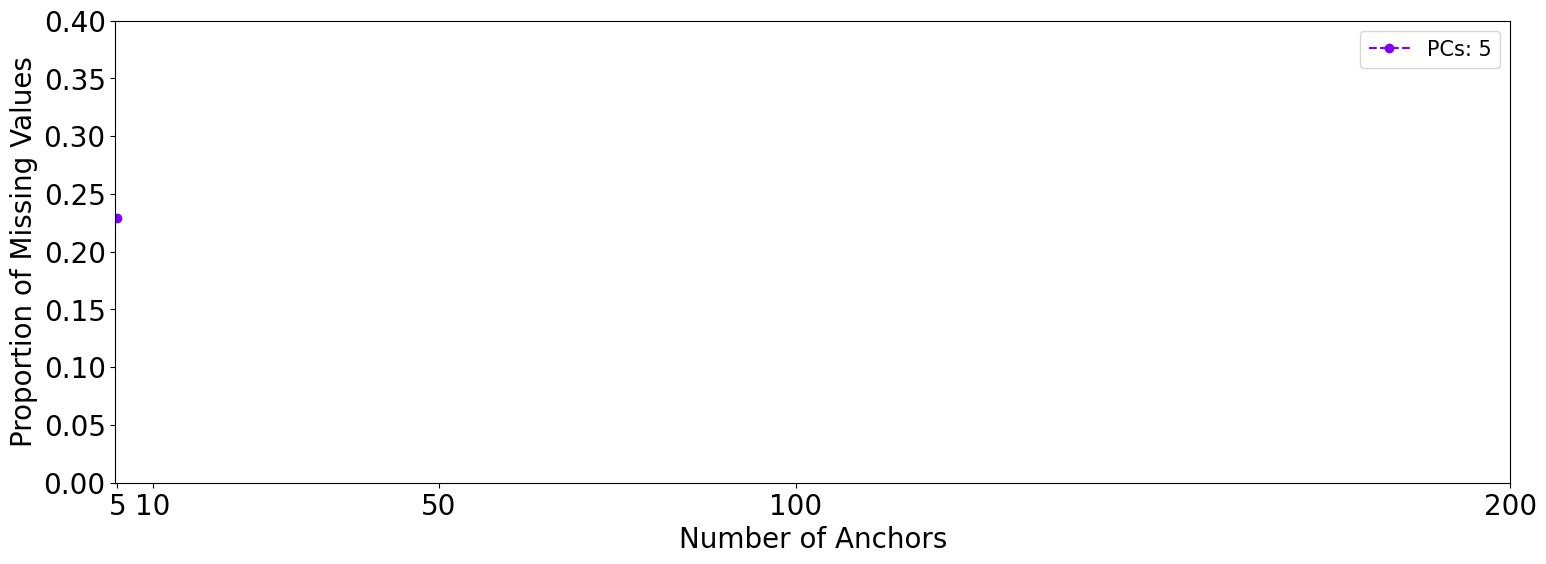

In [25]:
unique_n_pc = df["n_pc"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(18, 6))
plt.ylim(0, 0.4)

# Plot each line separately for each unique value in 'n_pc'
for i, n_pc in enumerate(unique_n_pc):
    subset_df = df[df["n_pc"] == n_pc]
    mean_values = subset_df.groupby("n_anchor")["stats_p_nan_after"].mean()
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker="o",
        linestyle="--",
        label=f"PCs: {int(n_pc)}" if n_pc > 0 else "Without ESM",
        color=colors[i],
    )

plt.xlabel("Number of Anchors", fontsize=20)
plt.xticks([5, 10, 50, 100, 200], fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel("Proportion of Missing Values", fontsize=20)
plt.legend(fontsize=15)

plt.show()

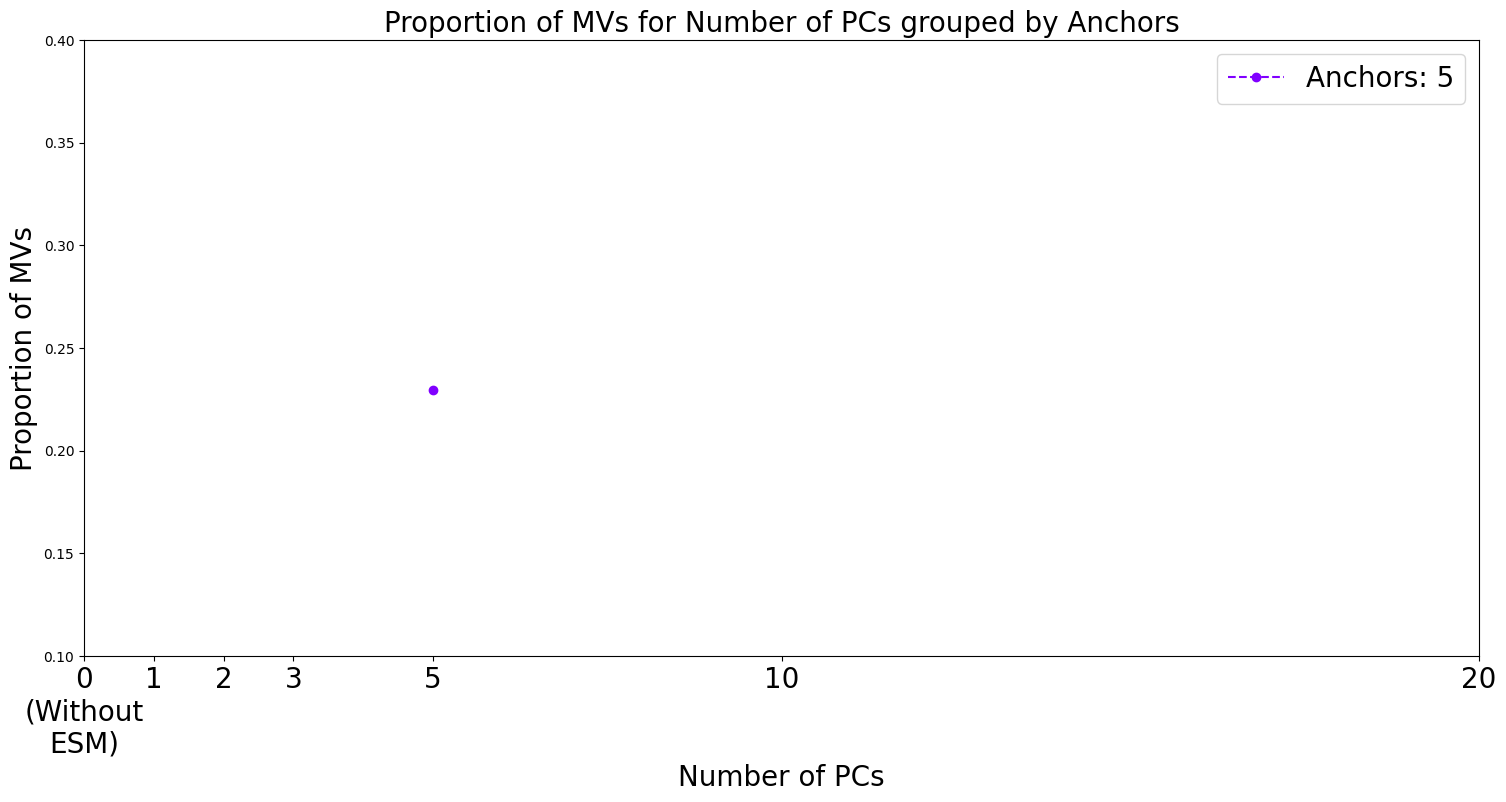

In [28]:
unique_n_anchors = df["n_anchor"].unique()

colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_anchors)))

plt.figure(figsize=(18, 8))
plt.ylim(0.1, 0.4)

# Plot each line separately for each unique value in 'n_pc'
for i, n_anchor in enumerate(unique_n_anchors):
    subset_df = df[df["n_anchor"] == n_anchor]
    mean_values = subset_df.groupby("n_pc")["stats_p_nan_after"].mean()
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker="o",
        linestyle="--",
        label=f"Anchors: {int(n_anchor)}",
        color=colors[i],
    )

plt.xlabel("Number of PCs", fontsize=20)
plt.xticks(
    [0, 1, 2, 3, 5, 10, 20], ["0\n(Without\nESM)", 1, 2, 3, 5, 10, 20], fontsize=20
)  # ,2,5,10
plt.ylabel("Proportion of MVs", fontsize=20)
plt.title("Proportion of MVs for Number of PCs grouped by Anchors", fontsize=20)
plt.legend(fontsize=20)

plt.show()